# Modelos de ensamble

Los **modelos de ensamble** (*ensemble models*) o **aprendizaje de ensamble** (*ensemble learning*) consisten en la construcción de **múltiples modelos** predictivos y su posterior **combinación** para obtener un resultado que, generalmente, es más preciso y robusto que el que se obtendría con cualquiera de los modelos individuales por separado,.

La filosofía detrás del aprendizaje de ensamble se basa en la idea de la **diversidad**: al combinar modelos que tienen diferentes perspectivas o sesgos sobre el problema, se **reduce el riesgo general** de seleccionar un modelo deficiente y se mejora la capacidad de **generalización**. Aprovechar la diversidad de los modelos, de modo que, al agregar las predicciones de varios "expertos" (los modelos base), se reduce el riesgo general de seleccionar una solución pobre o subóptima

### Mecanismos y Técnicas Clave
Para que los modelos de ensamble sean efectivos, es crucial que los modelos individuales exhiban diversidad, lo que les permite capturar diferentes matices en los datos y mejorar la capacidad de generalización. La diversidad se logra mediante varias estrategias:

1. Variación de Parámetros y Límites de Decisión: Los modelos individuales se entrenan utilizando diferentes parámetros de entrenamiento, lo que resulta en la generación de diferentes límites de decisión.

2. Muestreo de Datos (Bagging): Se utiliza la técnica de muestreo bootstrap (bootstrap sampling) para crear múltiples subconjuntos aleatorios del conjunto de datos de entrenamiento (con reemplazo).

3. Selección Aleatoria de Características: Especialmente en técnicas como Random Forest, se inyecta aleatoriedad al hacer que el modelo base use solo un subconjunto aleatorio de características del total disponible

### Componentes y Técnicas Clave

El aprendizaje de ensamble se utiliza en diversas aplicaciones, incluyendo la clasificación de datos, el modelado predictivo y la detección de anomalías. Algunas de las técnicas más reconocidas que emplean esta estrategia incluyen:

*   **Bagging (Bootstrap Aggregation):** Este es un método simple y potente que implica crear **múltiples submuestras** del conjunto de datos de entrenamiento **con reemplazo** (*bootstrap samples*),. Cada submuestra se utiliza para entrenar un modelo de forma independiente. La predicción final se obtiene mediante la combinación de las salidas de todos los modelos individuales (por ejemplo, a través de votación por mayoría para clasificación o promediando para regresión). Este proceso reduce la varianza y mejora la capacidad de generalización del modelo, mitigando el riesgo de seleccionar un modelo subóptimo.

*   **Bosques Aleatorios (*Random Forests*):** Es una forma de *bagging* donde los modelos base son **árboles de decisión**. Además de muestrear datos con reemplazo, los *Random Forests* introducen aleatoriedad al seleccionar solo un **subconjunto de características** en cada nodo antes de buscar la mejor división,. La salida final se determina por **votación** de todos los árboles en el "bosque".

*   **Boosting (Aumento):** Este método opera de forma **secuencial**, construyendo modelos uno tras otro para **corregir los errores** cometidos por los modelos anteriores. Asigna **pesos** a las instancias de entrenamiento, incrementando el peso de aquellas que fueron clasificadas incorrectamente para que el siguiente modelo se enfoque en ellas,. La predicción final es una **suma ponderada** de las predicciones de todos los modelos débiles. **AdaBoost** es un ejemplo clásico de un algoritmo de *boosting*.


## Ejemplos de Uso en Python

La implementación de modelos de ensamble en Python es sencilla utilizando la librería `scikit-learn` y, en contextos más avanzados, `imblearn`.

### Bagging
Un ejemplo avanzado y práctico de Bagging se da en el contexto de datos desbalanceados, donde una clase es mucho menos frecuente que la otra. Para esto, se utiliza la librería imblearn junto con scikit-learn.
El siguiente código muestra cómo configurar un clasificador de Bagging balanceado utilizando un Árbol de Decisión (DecisionTreeClassifier) como modelo base, basándose en la estructura y los módulos mencionados en las fuentes para técnicas de ensamble y manejo de datos desbalanceados

In [3]:
# Importar NumPy para la manipulación de arrays y datos [7]
import numpy as np

# Importar las clases necesarias de scikit-learn
# El Árbol de Decisión es un modelo de alta varianza frecuentemente usado como base para Bagging [3, 8, 9]
from sklearn.tree import DecisionTreeClassifier 

# Importar el BalancedBaggingClassifier de imblearn, ideal para datos desbalanceados [6]
from imblearn.ensemble import BalancedBaggingClassifier 

# ------------------- 1. Preparación de Datos (Simulación) -------------------
# Dado que no se especifica un dataset, se simulan datos básicos.
# En un entorno real, se cargaría un dataset con pandas o scikit-learn.

# Simulamos un conjunto de datos con 4 características (X) y una etiqueta (y)
X = np.array([
    [1.0, 2.0, 0.1, 0.5], [1.1, 2.1, 0.2, 0.4], [1.2, 2.2, 0.3, 0.6], [1.3, 2.3, 0.4, 0.7],
    [5.0, 6.0, 9.1, 9.5], [5.1, 6.1, 9.2, 9.4], [5.2, 6.2, 9.3, 9.6]
])
# Etiquetas desbalanceadas (Clase 0: 4 instancias; Clase 1: 3 instancias)
y = np.array([0, 0, 0, 0, 1, 1, 1])

# Nota: En un proceso real, el conjunto de datos se dividiría en entrenamiento y prueba (train_test_split) 
# antes de la fase de modelado para una evaluación precisa [10].

# ------------------- 2. Definición del Modelo de Bagging -------------------
# La inicialización del modelo de ensamble de Bagging Balanceado:
# Combina Bagging con una estrategia interna para remuestrear la clase minoritaria [6].

bbc_model = BalancedBaggingClassifier(
    # Establece el clasificador base (DecisionTree)
    estimator=DecisionTreeClassifier(), 
    # 'auto' indica que se use la estrategia de Bagging balanceado para muestrear equilibradamente [6]
    sampling_strategy='auto', 
    # Indicamos que el muestreo de las submuestras se haga sin reemplazo de la clase mayoritaria
    replacement=False, 
    # Fija la semilla para resultados reproducibles [11, 12]
    random_state=0
) 

# ------------------- 3. Entrenamiento y Predicción -------------------

# Entrenamiento del modelo de Bagging (en un entorno real se usarían datos de entrenamiento)
bbc_model.fit(X, y)

# Simulación de predicción para un nuevo dato:
X_new = np.array([[3.0, 4.0, 5.0, 5.0]]) 
prediccion = bbc_model.predict(X_new)

# Mostrar la clase predicha
print(f"\nPredicción del modelo Bagging (Clase: {prediccion})")


Predicción del modelo Bagging (Clase: [0])


Accuracy en test: 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Matriz de confusión:
[[39  3]
 [ 2 70]]

Ejemplo de predicción:
Clase predicha: 0 -> malignant
Probabilidad estimada (clase predicha): 1.0000

Top 10 características por importancia (promedio sobre estimadores):
 - worst perimeter: 0.2416
 - mean concave points: 0.1869
 - worst concave points: 0.1607
 - worst radius: 0.1483
 - worst area: 0.1265
 - worst texture: 0.0306
 - area error: 0.0178
 - mean texture: 0.0101
 - mean area: 0.0091
 - worst concavity: 0.0070


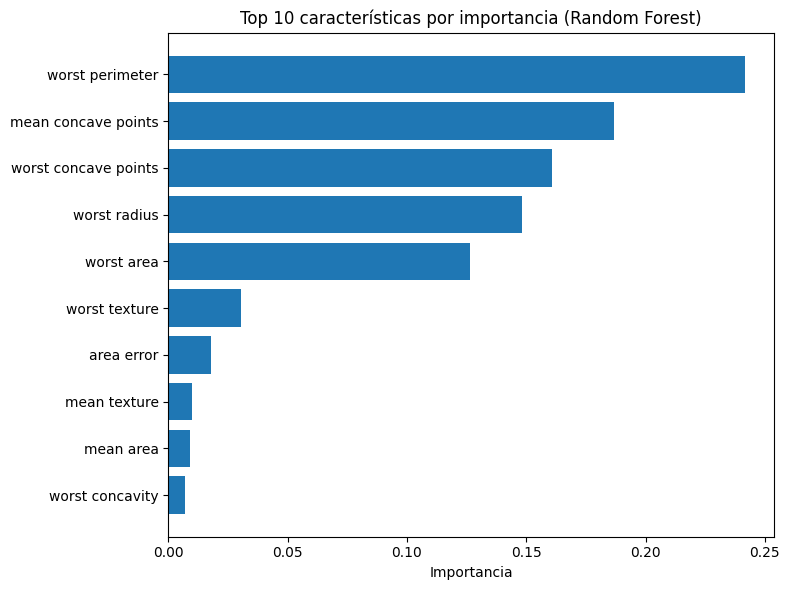

In [21]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ejemplo_bagging_breast_cancer.py
# Ejemplo completo y autocontenido de Bagging sobre el dataset "breast cancer"
# Incluye carga de datos, partición, entrenamiento, evaluación y predicción sobre un nuevo ejemplo.


RANDOM_STATE = 42

# 1. Cargar dataset
data = load_breast_cancer()
X = data.data
y = data.target
target_names = data.target_names

# 2. Dividir en entrenamiento / prueba (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# 3. Definir el modelo Bagging con DecisionTree como estimador base
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=50,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# 4. Entrenar
bag_model.fit(X_train, y_train)

# 5. Evaluar en conjunto de prueba
y_pred = bag_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy en test: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# 6. Predicción sobre un nuevo ejemplo
# Usamos una fila del conjunto de prueba como ejemplo nuevo
sample = X_test[0].reshape(1, -1)
pred_class_idx = bag_model.predict(sample)[0]
pred_proba = bag_model.predict_proba(sample)[0, pred_class_idx] if hasattr(bag_model, "predict_proba") else None

print("\nEjemplo de predicción:")
print(f"Clase predicha: {pred_class_idx} -> {target_names[pred_class_idx]}")
if pred_proba is not None:
    print(f"Probabilidad estimada (clase predicha): {pred_proba:.4f}")

# 7. (Opcional) Promedio de importancias de características a partir de los árboles
# BaggingClassifier no expone importances directamente; calculamos la media si los estimadores lo permiten.
try:
    importances = np.mean([est.feature_importances_ for est in bag_model.estimators_], axis=0)
    top_k = 10
    top_idx = np.argsort(importances)[::-1][:top_k]
    feature_names = data.feature_names
    print(f"\nTop {top_k} características por importancia (promedio sobre estimadores):")
    for i in top_idx:
        print(f" - {feature_names[i]}: {importances[i]:.4f}")
except Exception:
    # si algún estimador no tiene feature_importances_ (no debería ocurrir con DecisionTree)
    pass

plt.figure(figsize=(8, 6))
plt.barh(np.arange(top_k)[::-1], importances[top_idx], align='center')
plt.yticks(np.arange(top_k)[::-1], feature_names[top_idx])
plt.xlabel("Importancia")
plt.title(f"Top {top_k} características por importancia (Random Forest)")
plt.tight_layout()
plt.show()

### Random Forest

Accuracy en test: 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Matriz de confusión:
[[39  3]
 [ 2 70]]

Predicción para el ejemplo de muestra: clase = benign, prob = 0.9900


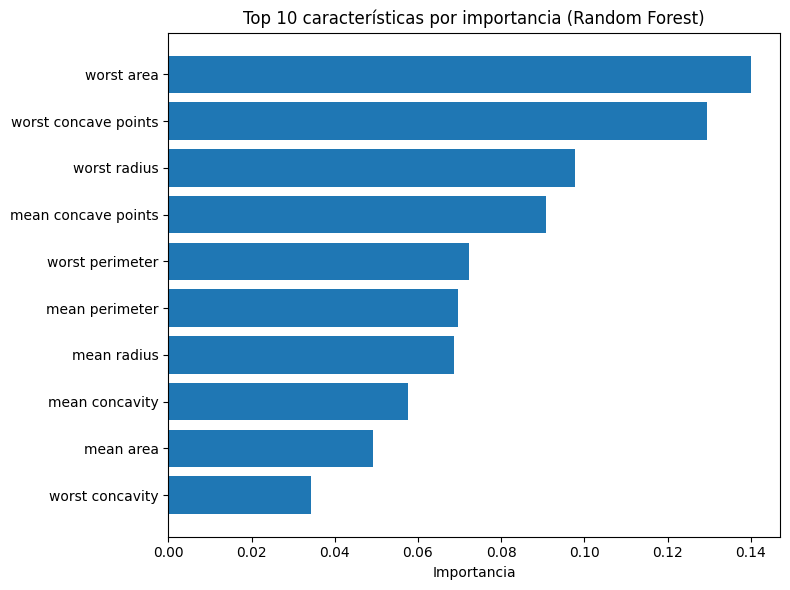

In [ ]:
# Ejemplo completo y autocontenido de Random Forest con el dataset breast cancer
# Carga, partición, entrenamiento, evaluación y predicción sobre un nuevo ejemplo.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

import matplotlib.pyplot as plt

# 1. Cargar dataset
data = load_breast_cancer()

X_bc = data.data
y_bc = data.target
feature_names = data.feature_names

# 2. Dividir en entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.20, stratify=y_bc, random_state=42
)

# 3. Inicializar y entrenar el modelo Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 4. Evaluación en el conjunto de prueba
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy en test: {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# 5. Predicción sobre un nuevo ejemplo (a partir de una fila del test set)
sample = X_test[5].reshape(1, -1)  # ejemplo nuevo
pred_class = rf.predict(sample)[0]
pred_proba = rf.predict_proba(sample)[0, pred_class]
print(f"\nPredicción para el ejemplo de muestra: clase = {data.target_names[pred_class]}, prob = {pred_proba:.4f}")

# 6. Importancias de características (top 10) — visualización
importances = rf.feature_importances_
idx_sorted = np.argsort(importances)[::-1]
top_k = 10
top_idx = idx_sorted[:top_k]

plt.figure(figsize=(8, 6))
plt.barh(np.arange(top_k)[::-1], importances[top_idx], align='center')
plt.yticks(np.arange(top_k)[::-1], feature_names[top_idx])
plt.xlabel("Importancia")
plt.title(f"Top {top_k} características por importancia (Random Forest)")
plt.tight_layout()
plt.show()



1.  **Clasificación con Bosques Aleatorios (*Random Forests*):**
    Los *Random Forests* son un ejemplo primordial de modelos de ensamble. Se utilizan clases como `RandomForestClassifier` o `ExtraTreesClassifier` en `scikit-learn`. Un ejemplo de su uso para construir un clasificador sería:

    ```python
    from sklearn.ensemble import RandomForestClassifier

    # Inicialización del modelo con 100 estimadores (árboles)
    model = RandomForestClassifier(n_estimators=100) 

    # El modelo se ajustaría posteriormente con los datos de entrenamiento
    ```

2.  **Modelos de Ensamble para Datos Desbalanceados:**
    Los modelos de ensamble son una técnica efectiva para abordar conjuntos de datos donde las clases son desbalanceadas, ayudando a equilibrar la precisión. La librería `imblearn` ofrece herramientas para esto, como el `BalancedBaggingClassifier`:

    ```python
    from imblearn.ensemble import BalancedBaggingClassifier
    from sklearn.tree import DecisionTreeClassifier

    # Combina un clasificador base (árbol de decisión) con bagging balanceado
    bbc = BalancedBaggingClassifier(base_estimator=DecisionTreeClassifier()) 
    ```
    Este enfoque ayuda a que la máquina de ensamble tome **muestras de entrenamiento equilibradas**, lo cual es crucial cuando se detectan casos minoritarios,. En un caso de estudio, el Bosque Aleatorio demostró una **mejor clasificación** en comparación con otros algoritmos en conjuntos de datos muy desiguales.

En esencia, un modelo de ensamble funciona como un **meta-modelo** que fusiona las "opiniones" de múltiples modelos base a través de un mecanismo de agregación, lo que resulta en una **mayor precisión** en el resultado final,.

## Boosting
El **boosting** (o *Aumento*) es un método fundamental dentro del **aprendizaje de ensamble** (*ensemble learning*) que busca crear un **clasificador fuerte** combinando secuencialmente las predicciones de múltiples **clasificadores débiles** o "aprendices base".

La característica principal del *boosting* es su naturaleza **secuencial** e **iterativa**, donde los modelos se construyen uno tras otro. La finalidad de cada modelo que se añade es **corregir los errores** cometidos por los modelos construidos en los pasos anteriores.

### Mecanismo Clave

El proceso de *boosting* consigue esta corrección secuencial utilizando un sistema de **ponderación de datos** que se ajusta iterativamente:

1.  El algoritmo identifica los **ejemplos de entrenamiento más difíciles** o aquellos que fueron clasificados incorrectamente por los modelos previos.

2.  Incrementa el **peso** de estas instancias mal clasificadas, asegurando que el nuevo modelo se centre en aprender de ellas y corregir esos fallos en la siguiente iteración.

3.  La predicción final se obtiene mediante una **suma ponderada** de las salidas de todos los modelos débiles que componen el ensamble.

El *boosting* se justifica en la idea de que entrenar un clasificador débil mediante la manipulación apropiada de los datos (ponderación) puede resultar en un clasificador fuerte.

### Algoritmos de Boosting

Existen diversas implementaciones del *boosting* que son ampliamente utilizadas:

*   **AdaBoost (Adaptive Boosting):** Es un algoritmo clásico que utiliza esta filosofía de ajuste secuencial de pesos y minimiza la pérdida exponencial (*exponential loss*).

*   **Gradient Boosting (Aumento de Gradiente):** Esta variante construye modelos, a menudo árboles de decisión poco profundos, utilizando el concepto de **gradiente** para minimizar la función de pérdida.

*   **XGBoost (Extreme Gradient Boosting):** Es una forma avanzada de *gradient boosting* que utiliza aproximaciones más detalladas, como el cálculo de **gradientes de segundo orden** de la función de pérdida, e incorpora **regularización (L1 y L2)** para reducir el sobreajuste y mejorar la generalización.

El éxito de los métodos de *boosting*, especialmente aquellos que usan árboles, se debe a que son esquemas de aprendizaje muy potentes y a menudo se encuentran entre los de mejor rendimiento en problemas de clasificación y minería de datos.

### **Adaboost**
El algoritmo **AdaBoost** (Aumento Adaptativo) es un método fundamental dentro del **aprendizaje de ensamble** (*ensemble learning*) que se caracteriza por construir un **clasificador fuerte** a partir de una secuencia de **clasificadores débiles**.

A diferencia de otros métodos de ensamble que construyen modelos en paralelo (como Random Forest), AdaBoost es un esquema **iterativo y secuencial**, donde los modelos se construyen uno después de otro para **corregir los errores** cometidos por sus predecesores. La filosofía central de AdaBoost es, por tanto, que cada modelo consecutivo se entrena para corregir los errores cometidos por los modelos predecesores, en lugar de ser entrenados de forma independiente.

### Mecanismo Operativo y Ponderación

La estrategia central de AdaBoost se basa en la **ponderación adaptativa** de los datos de entrenamiento. En cada iteración, el algoritmo:

1. **Modelos Base (Aprendices Débiles)**: Identifica los **puntos de datos más difíciles** de clasificar, es decir, aquellos que el modelo anterior clasificó incorrectamente.

2. **Ponderación de Datos**: En cada iteración, el algoritmo ajusta la distribución de pesos de las muestras de entrenamiento. El peso de las instancias que fueron clasificadas incorrectamente por el modelo anterior se incrementa, forzando al siguiente modelo débil a concentrarse en clasificar correctamente esos ejemplos difíciles (hard samples

Este proceso asegura que las muestras que fallan repetidamente en ser clasificadas correctamente **ganan importancia** en el cálculo del error empírico ponderado.

#### Función de Pérdida y Algoritmo Codicioso

3. **Función de Pérdida:** AdaBoost opera optimizando una **función de costo** específica, a menudo la **función de pérdida exponencial** (*exponential loss*), definida como:

 $$L(y,F(x))=exp(−yF(x))$$
 
 Esta función tiene la propiedad de **ponderar más fuertemente** los puntos que el clasificador anterior predijo incorrectamente (mal clasificadas) ($yF(x) < 0$).

4. **Cálculo del Coeficiente ($a_i$)**: el algoritmo selecciona el clasificador débil óptimo y calcula su **coeficiente de influencia** ($a_i$), también conocido como *stage value*, mediante la minimización de la pérdida exponencial de forma "codiciosa" (*greedy*). Este coeficiente se calcula en función **tasa de error ponderado** ($P_i$) que comete el clasificador base:

$$a_{i}=\frac{1}{2} \ln \frac{1-P_{i}}{P_{i}}$$

Si la tasa de error ($P_i$) es menor a $0.5$ (es decir, el clasificador es mejor que el azar), el coeficiente $a_i$ será positivo, otorgándole un **peso positivo** en la decisión final del ensamble.

5. **Predicción Final**: La predicción del ensamble se obtiene mediante una suma ponderada de las salidas de todos los clasificadores débiles secuenciales. Si esta suma es positiva, se predice la primera clase; si es negativa, la segunda clase

### Clasificadores Débiles

AdaBoost se utiliza habitualmente para **aumentar el rendimiento de los árboles de decisión**. Un clasificador base muy común en AdaBoost es el **"tocón de decisión"** (*decision stump*), un árbol de decisión de **un solo nivel** que realiza únicamente una división. Estos son considerados "modelos débiles" que, aunque tienen una precisión ligeramente superior a la aleatoria, se combinan para formar un clasificador final de alta precisión.

### Ventajas y Desventajas

*   **Ventajas:** Es un **clasificador adaptativo** que mejora significativamente la eficiencia del modelo. Al combinar modelos, la predicción final es una **suma ponderada** de todos los clasificadores base diseñados jerárquicamente.
*   **Desventajas:** Es **sensible a datos ruidosos y valores atípicos** (*outliers*). Si el algoritmo se entrena en exceso, puede provocar **sobreajuste** (*overfitting*).

### Ejemplo de Uso en Python

AdaBoost es primordialmente utilizado para problemas de **clasificación binaria**. La implementación estándar se realiza a través de la librería `scikit-learn`.

El uso más común implica emplear los árboles de decisión como estimadores base, ya sea para clasificación (`AdaBoostClassifier`) o regresión (`AdaBoostRegressor`). Por ejemplo, en el contexto de la **regresión**, se puede definir un `AdaBoostRegressor` que utiliza un `DecisionTreeRegressor` como modelo individual para calcular la importancia de las características (una aplicación del algoritmo):

```python
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor

# Definir el clasificador base (un árbol de regresión)
base_estimator = DecisionTreeRegressor(max_depth=4) 

# Inicializar AdaBoost con 400 estimadores
regressor = AdaBoostRegressor(
    base_estimator=base_estimator, 
    n_estimators=400, 
    random_state=7
)

# El modelo se ajustaría posteriormente con los datos de entrenamiento para predecir.
# regressor.fit(X_train, y_train) 
```

El resultado de AdaBoost es una **predicción agregada**. En la clasificación, esta se resuelve mediante una suma ponderada de las salidas de los clasificadores débiles. Si la suma total de las predicciones ponderadas es positiva, se elige una clase; si es negativa, se elige la otra.

Accuracy (test): 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix:
[[38  4]
 [ 1 71]]

ROC AUC (test): 0.9848

Ejemplo de predicción: clase = 0 (malignant), prob = 0.7780273759977083


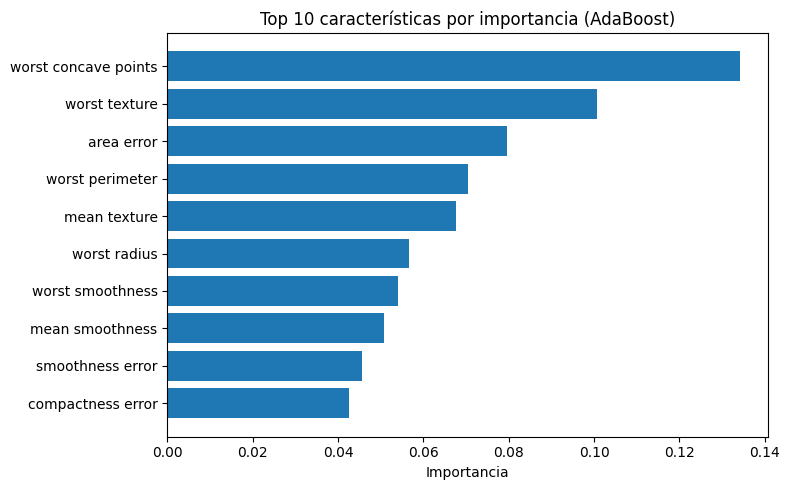

In [25]:
# Ejemplo de uso de AdaBoost para clasificación binaria
# Dataset: Breast Cancer Wisconsin (diagnóstico) — esquema binario (malignant / benign)

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
import numpy as np

import matplotlib.pyplot as plt

RANDOM_STATE = 42

# 1) Cargar datos
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# 2) Partición entrenamiento / prueba (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# 3) Definir estimador base (stump: árbol muy poco profundo) y AdaBoost
base_stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
adb = AdaBoostClassifier(
    estimator=base_stump,   # parámetro 'estimator' (base_estimator está deprecado)
    n_estimators=200,
    learning_rate=0.5,
    random_state=RANDOM_STATE
)

# 4) Entrenamiento
adb.fit(X_train, y_train)

# 5) Evaluación en test
y_pred = adb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (test): {acc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# AUC (probabilidades)
if hasattr(adb, "predict_proba"):
    y_proba = adb.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    print(f"\nROC AUC (test): {auc:.4f}")

# 6) Predicción de ejemplo nuevo (primera fila del test)
sample = X_test[0].reshape(1, -1)
pred = adb.predict(sample)[0]
proba = adb.predict_proba(sample)[0, pred] if hasattr(adb, "predict_proba") else None
print(f"\nEjemplo de predicción: clase = {pred} ({target_names[pred]}), prob = {proba}")

# 7) Importancia de características (AdaBoost con árboles expone feature_importances_)
try:
    importances = adb.feature_importances_
    idx_sorted = np.argsort(importances)[::-1]
    top_k = 10
    top_idx = idx_sorted[:top_k]

    plt.figure(figsize=(8, 5))
    plt.barh(np.arange(top_k)[::-1], importances[top_idx], align='center')
    plt.yticks(np.arange(top_k)[::-1], feature_names[top_idx])
    plt.xlabel("Importancia")
    plt.title(f"Top {top_k} características por importancia (AdaBoost)")
    plt.tight_layout()
    plt.show()
except Exception:
    pass

### **Gradient Boosting**

El **Gradient Boosting** (Aumento de Gradiente) es un método avanzado dentro del **aprendizaje de ensamble** (*ensemble learning*) que sigue la filosofía del *boosting*: construir un clasificador fuerte y preciso mediante la **combinación secuencial** de múltiples clasificadores débiles, corrigiendo los errores de los modelos anteriores [Conversational History].

El aspecto distintivo de esta técnica reside en la forma en que se realiza la corrección y optimización en cada etapa de la secuencia:

#### Mecanismo de Optimización mediante Gradientes

El Gradient Boosting opera minimizando una **función de pérdida** (*loss function*) predefinida (o función de costo). A diferencia de los métodos de *boosting* anteriores (como AdaBoost, que se centra en reponderar las instancias de datos mal clasificadas), el Gradient Boosting utiliza el concepto matemático de **gradiente** para orientar el entrenamiento de los nuevos modelos.

*   **Minimización de la Función de Pérdida:** El algoritmo busca reducir la función de pérdida de manera iterativa. Esto es similar a cómo las **redes neuronales** utilizan el descenso de gradiente para optimizar sus pesos.
*   **Gradientes de Alto Orden:** Los algoritmos que implementan Gradient Boosting de manera avanzada, como **Extreme Gradient Boosting (XGBoost)**, son conocidos por utilizar **aproximaciones más detalladas**. XGBoost, por ejemplo, calcula **gradientes de segundo orden** de la función de pérdida para encontrar el mejor modelo en cada paso.

Este enfoque de optimización ha posicionado a los algoritmos de Gradient Boosting entre los esquemas de aprendizaje más potentes y de alto rendimiento en problemas de clasificación y regresión. XGBoost, junto con otros como LightGBM, pertenece a la familia de modelos basados en árboles (*Tree-Based*) y ha demostrado ser capaz de superar en rendimiento a las redes neuronales en ciertos conjuntos de datos.

#### Ejemplo de Uso en Python (Clasificación y Regresión)

En Python, la implementación de las técnicas de *boosting* se realiza a través de librerías como `scikit-learn`. El algoritmo AdaBoost (Aumento Adaptativo), que establece la base secuencial de la que se derivan los métodos de gradiente, es un ejemplo fundamental de esta familia.

El siguiente ejemplo muestra cómo configurar un **AdaBoost Regressor** en Python, utilizando un **Árbol de Decisión** (`DecisionTreeRegressor`) como el modelo individual débil, un patrón común en los métodos de *boosting* basados en árboles. Esta configuración se utiliza a menudo para calcular la importancia de las características (*feature importance*) en un conjunto de datos:

```python
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.utils import shuffle

# Se asume que X_train y y_train están definidos y contienen los datos de entrenamiento

# 1. Definir el estimador base (árbol de decisión, típicamente poco profundo para Boosting)
base_estimator = DecisionTreeRegressor(max_depth=4) 

# 2. Inicializar AdaBoost Regressor con el estimador base y el número de árboles
regressor = AdaBoostRegressor(
    base_estimator=base_estimator, 
    n_estimators=400, 
    random_state=7
)

# El modelo se ajustaría posteriormente con los datos de entrenamiento
# regressor.fit(X_train, y_train)
# ... (Luego se usa para estimar el rendimiento o la importancia de las características)
```
Este código ilustra la estructura para definir y entrenar un algoritmo de ensamble secuencial en Python, utilizando **400 estimadores** y un árbol de decisión como base, tal como se menciona en las fuentes para el uso de `AdaBoostRegressor`.

### **XGBoost**

**XGBoost** (Extreme Gradient Boosting) es un algoritmo avanzado de **aprendizaje de ensamble** (*ensemble learning*) que se distingue por su alta eficiencia y rendimiento, y que es considerado una de las implementaciones más potentes del método de **Boosting por Gradiente** (*Gradient Boosting*).

El *boosting* en general opera secuencialmente, construyendo modelos débiles (como árboles de decisión) de forma iterativa para corregir los errores del modelo anterior (AdaBoost). XGBoost toma este concepto y lo optimiza rigurosamente:

### Características Clave de XGBoost

1.  **Optimización por Gradiente de Segundo Orden:** A diferencia de los algoritmos de *boosting* más sencillos que utilizan información de primer orden (el gradiente) para la optimización, XGBoost utiliza **gradientes de segundo orden** (como la matriz Hessiana) en la función de pérdida. Este enfoque proporciona una aproximación más precisa para encontrar el mínimo de la función de costo en cada paso, lo que resulta en una selección de modelo más efectiva y eficiente (Gradient Boosting).

2.  **Regularización Integral:** XGBoost incorpora mecanismos avanzados de **regularización** (tanto L1 como L2) directamente en la función de costo durante la construcción de los árboles [CH: Gradient Boosting]. La regularización es una técnica utilizada para mitigar la magnitud de los parámetros y hacer que el modelo sea **menos sensible a los datos de entrenamiento**, previniendo el **sobreajuste** (*overfitting*) y mejorando su capacidad de **generalización**. La regularización L1 (Lasso) penaliza la suma de los valores absolutos de los coeficientes, mientras que la L2 (Ridge) penaliza la suma de los cuadrados de los coeficientes.

3.  **Rendimiento Superior:** Debido a su optimización detallada y robusta, XGBoost se ha establecido como un esquema de aprendizaje muy poderoso y a menudo figura entre los algoritmos de **mejor rendimiento** en problemas complejos de clasificación y minería de datos [CH: AdaBoost, Gradient Boosting]. Se ha notado que, en ciertos conjuntos de datos, los modelos basados en árboles como XGBoost y LightGBM han logrado superar a las redes neuronales en precisión.

### Ejemplo de Uso en Python

Para implementar XGBoost, se utiliza generalmente una biblioteca externa optimizada (a diferencia de otros algoritmos que pueden estar incluidos en `scikit-learn`), pero su uso sigue la misma metodología de instanciación, ajuste y predicción que otros modelos de ensamble.

El siguiente ejemplo muestra la estructura típica para inicializar un modelo XGBoost para un problema de clasificación utilizando su librería dedicada:

```python
# Nota: La implementación de XGBoost requiere la instalación de una librería específica (xgboost).

import xgboost as xgb 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Preparación de datos (simulados)
# X representa las características, y representa las etiquetas de clase
X = np.array([,,,,])
y = np.array()

# Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Inicialización y entrenamiento del modelo
# Utiliza un clasificador de XGBoost. Se pueden ajustar hiperparámetros como n_estimators.
model = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100, use_label_encoder=False, eval_metric='logloss')

# Entrenamiento
model.fit(X_train, y_train)

# 3. Predicción y evaluación
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Precisión del modelo XGBoost: {accuracy}")
```

Este código refleja el proceso estándar en Python para ajustar un modelo predictivo, aprovechando la potencia de XGBoost como un clasificador de ensamble de alto rendimiento. La fase de **optimización de hiperparámetros** (mencionada como una temática clave de la optimización de modelos) es crucial para obtener el máximo rendimiento de XGBoost, donde se ajustan parámetros como la profundidad máxima del árbol (`max_depth`) o la tasa de aprendizaje (`learning_rate`) para encontrar el equilibrio perfecto entre sesgo y varianza.

### **LightGBM**

El algoritmo **LightGBM** (Light Gradient Boosting Machine) se inscribe dentro de la categoría de los modelos de **Boosting por Gradiente** (*Gradient Boosting*), una técnica de **aprendizaje de ensamble** (*ensemble learning*) que construye predictores de forma secuencial para corregir errores previos.

### Descripción General

LightGBM es un algoritmo altamente eficiente que pertenece a la familia de modelos **basados en árboles** (*Tree-Based*). Se le menciona consistentemente junto con **XGBoost** como una de las implementaciones más potentes de *Gradient Boosting*.

*   **Rendimiento Destacado:** Los modelos basados en árboles, incluyendo LightGBM y XGBoost, han demostrado la capacidad de **superar el rendimiento** de las redes neuronales en ciertos problemas de clasificación y minería de datos.

### Uso y Contexto en Python

Aunque LightGBM es un componente clave en el ecosistema de *boosting* en Python, las fuentes proporcionadas se centran principalmente en las implementaciones de *ensemble learning* disponibles en librerías como `scikit-learn` o `imblearn`, como los Bosques Aleatorios (`RandomForestClassifier`) y AdaBoost (Bagging, AdaBoost, Random Forest).


[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.019751 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

/home/patricioaraneda/Documentos/github/kibernum/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/patricioaraneda/Documentos/github/kibernum/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


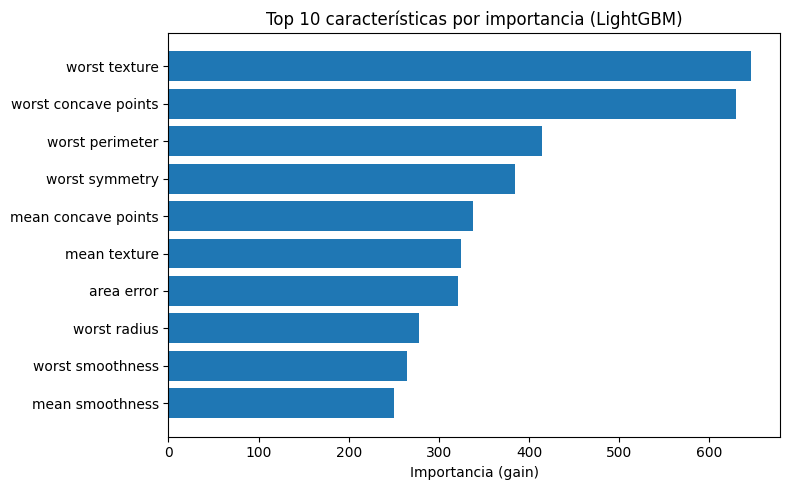

In [44]:
# Ejemplo autocontenido de LightGBM (clasificación) sobre el dataset Breast Cancer
# Incluye: carga de datos, partición, entrenamiento, métricas, importancia de características y predicción.

import sys
import lightgbm as lgb
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# 1) Cargar dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

# 2) Partición entrenamiento / prueba (estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# 3) Inicializar el modelo LightGBM
model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 4) Entrenamiento con evaluación temprana sobre el conjunto de validación (test aquí, en producción usar validación separada)
# Algunas versiones del wrapper sklearn de LightGBM no aceptan el parámetro `early_stopping_rounds`
# directamente en fit. Usamos `callbacks` para compatibilidad:
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='auc',
    #callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(period=0)]
)

# 5) Predicción y métricas
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy (test): {acc:.4f}")
print(f"ROC AUC (test): {auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 6) Importancia de características (Top 10)
importances = model.feature_importances_
idx_sorted = np.argsort(importances)[::-1]
top_k = 10
top_idx = idx_sorted[:top_k]

plt.figure(figsize=(8, 5))
plt.barh(np.arange(top_k)[::-1], importances[top_idx], align='center')
plt.yticks(np.arange(top_k)[::-1], feature_names[top_idx])
plt.xlabel("Importancia (gain)")
plt.title(f"Top {top_k} características por importancia (LightGBM)")
plt.tight_layout()
plt.show()


In [50]:
# mostrar filas del test 'X_test' como dataframe

print("\nprimeras filas del conjunto de prueba X_test:")
display(pd.DataFrame(X_test, columns=feature_names).head())



primeras filas del conjunto de prueba X_test:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,19.55,28.77,133.60,1207.0,0.09260,0.20630,0.17840,0.11440,0.1893,0.06232,...,25.05,36.27,178.60,1926.0,0.1281,0.53290,0.4251,0.19410,0.2818,0.10050
1,11.13,16.62,70.47,381.1,0.08151,0.03834,0.01369,0.01370,0.1511,0.06148,...,11.68,20.29,74.35,421.1,0.1030,0.06219,0.0458,0.04044,0.2383,0.07083
2,13.82,24.49,92.33,595.9,0.11620,0.16810,0.13570,0.06759,0.2275,0.07237,...,16.01,32.94,106.00,788.0,0.1794,0.39660,0.3381,0.15210,0.3651,0.11830
3,16.50,18.29,106.60,838.1,0.09686,0.08468,0.05862,0.04835,0.1495,0.05593,...,18.13,25.45,117.20,1009.0,0.1338,0.16790,0.1663,0.09123,0.2394,0.06469
4,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.45,26.40,166.10,2027.0,0.1410,0.21130,0.4107,0.22160,0.2060,0.07115


In [70]:

# 7) Predicción sobre un nuevo ejemplo (usar la primera fila del test como ejemplo)
sample = X_test[5].reshape(1, -1)

pred_class = model.predict(sample)[0]
pred_proba = model.predict_proba(sample)[0, pred_class]

print(f"\nPredicción ejemplo: clase = {pred_class} ({target_names[pred_class]}), prob = {pred_proba:.4f}")


Predicción ejemplo: clase = 1 (benign), prob = 1.0000


/home/patricioaraneda/Documentos/github/kibernum/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/patricioaraneda/Documentos/github/kibernum/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [71]:
# prediccion sobre un grupo de 5 casos de X_test
samples = X_test[:5]

pred_classes = model.predict(samples)
pred_probas = model.predict_proba(samples)

for i, (cls, proba) in enumerate(zip(pred_classes, pred_probas)):
    print(f"Ejemplo {i}: clase = {cls} ({target_names[cls]}), prob = {proba[cls]:.4f}")
    #print(f"  Características: {samples[i]}")

 

Ejemplo 0: clase = 0 (malignant), prob = 1.0000
Ejemplo 1: clase = 1 (benign), prob = 1.0000
Ejemplo 2: clase = 0 (malignant), prob = 1.0000
Ejemplo 3: clase = 0 (malignant), prob = 0.9825
Ejemplo 4: clase = 0 (malignant), prob = 1.0000


/home/patricioaraneda/Documentos/github/kibernum/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/patricioaraneda/Documentos/github/kibernum/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(




### 📊 **Tabla Comparativa: Algoritmos Basados en Árboles**

| Característica | **Random Forest** | **AdaBoost** | **Gradient Boosting** | **XGBoost** | **LightGBM** |
|------------------------------|-------------------|--------------|-------------------------------|-------------|--------------|
| **Tipo principal** | Ensemble (bagging) | Ensemble (boosting) | Ensemble (boosting secuencial) | Ensemble (boosting optimizado) | Ensemble (boosting ultra-optimizado) |
| **Clasificación** | ⭐⭐⭐⭐☆ (Muy bueno, robusto) | ⭐⭐⭐☆☆ (Bueno, sensible a ruido) | ⭐⭐⭐⭐☆ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Regresión** | ⭐⭐⭐⭐☆ | ⭐⭐☆☆☆ (Menos común, no ideal) | ⭐⭐⭐⭐☆ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Sobreajuste (Overfitting)** | ✅ **Muy resistente** (por promedio de árboles independientes) | ❌ **Muy sensible** (refuerza errores, propenso a ruido) | ⚠️ Moderadamente sensible | ⚠️ Puede sobreajustar si no se regulariza | ⚠️ **Más propenso** (por crecimiento *leaf-wise*); requiere control de `num_leaves` |
| **Datos desbalanceados** | ⚠️ Moderado (se puede mejorar con `class_weight`) | ❌ Malo (se enfoca en errores, que suelen ser minoritarios ruidosos) | ⚠️ Moderado | ✅ **Bueno** (admite `scale_pos_weight`, focal loss, etc.) | ✅ **Muy bueno** (admite `is_unbalance`, `scale_pos_weight`, métricas como AUC) |
| **Presencia de outliers** | ✅ **Muy robusto** (los árboles individuales los aíslan) | ❌ **Muy sensible** (los outliers generan errores grandes que se reforzarán) | ⚠️ Sensible (usa pérdida cuadrática en regresión) | ⚠️/✅ (admite funciones de pérdida robustas como *huber*) | ⚠️/✅ (admite pérdidas robustas y manejo de gradiente) |
| **Volumen de datos (escalabilidad)** | ⚠️ Escalable, pero lento en entrenamiento con muchos árboles | ❌ Poco escalable (secuencial, lento en grandes datos) | ❌ Lento (entrenamiento secuencial, sin optimización) | ✅ Muy escalable (paralelismo, cache-friendly) | ✅✅ **El más rápido y eficiente en memoria** (GOSS, EFB, histogramas) |
| **Características categóricas** | ✅ Maneja bien (internamente usa splits) | ❌ Requiere codificación previa | ❌ Requiere codificación previa | ⚠️ Requiere codificación (one-hot o label) | ✅✅ **Soporte nativo** (sin one-hot, evita explosión dimensional) |
| **Valores faltantes** | ✅ Maneja internamente | ❌ Requiere imputación previa | ❌ Requiere imputación | ✅ Maneja internamente | ✅✅ **Manejo nativo y eficiente** |
| **Interpretación / Explicabilidad** | ✅ Fácil (importancia por splits o impureza) | ✅ Moderada (pesos de muestras) | ⚠️ Difícil (modelo secuencial) | ✅ Buena (importancia, SHAP rápido) | ✅✅ **Excelente** (SHAP nativo y rápido, TreeSHAP) |
| **Casos de uso ideales** | - Prototipado rápido<br>- Datos con ruido/outliers<br>- Menos preocupación por overfitting<br>- Pequeños o medianos datasets | - Datasets limpios y pequeños<br>- Clasificación binaria simple<br>- Cuando se tiene un weak learner muy débil | - Datasets pequeños-medianos<br>- Cuando se quiere entender boosting básico | - Competencias de ML (Kaggle)<br>- Datasets medianos/grandes<br>- Necesidad de alto rendimiento y control fino | - **Grandes datasets tabulares**<br>- Sistemas en producción con restricciones de tiempo/memoria<br>- Datos con muchas categóricas<br>- Aplicaciones que requieren explicabilidad (SHAP) |

---

### 🔑 Leyenda de símbolos:
- ⭐: Nivel de desempeño (más estrellas = mejor)

- ✅: Buen manejo / recomendado

- ⚠️: Manejo limitado / requiere ajustes

- ❌: Pobre manejo / no recomendado

---

### 💡 Conclusiones clave para principiantes:

- **Empieza con Random Forest** si tu prioridad es rapidez, robustez y simplicidad, especialmente con datos ruidosos o pequeños.

- **Usa LightGBM** si trabajas con **grandes volúmenes de datos tabulares** (miles/millones de filas), tienes características categóricas y necesitas velocidad + precisión.

- **Elige XGBoost** si buscas un equilibrio entre control, rendimiento y estabilidad, y estás en competencias o entornos donde la reproducibilidad es clave.

- **Evita AdaBoost** en datos ruidosos o con outliers; es más útil como concepto educativo o en casos muy controlados.

- **Gradient Boosting clásico** (de `sklearn`) es útil para entender la base del boosting, pero en la práctica se prefiere XGBoost o LightGBM.

Esta tabla te servirá como guía rápida para seleccionar el algoritmo más adecuado según las características de tus datos y tus objetivos de modelado.